In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *


In [2]:
import torch
from torch import nn                                        # nn 모듈
from torch.optim import Adam                                # 최적화
# 파이토치에서 데이터를 다룰 때 사용하는 도구들
from torch.utils.data import TensorDataset, DataLoader 

In [3]:
# 디바이스 준비 (GPU, CPU)
# 파이토치 설치 : GPU 버전으로 설치 -> GPU도 사용할 수 있고. CPU도 사용할 수 있다
# CPU버전으로 설치하면 CPU만 사용하게 된다. 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
# 데이터 전처리 1
# 데이터 불러오기
path = 'https://bit.ly/advertising_csv'
adv = pd.read_csv(path)


# x, y 분할
target = 'Sales'
x = adv.drop(target, axis=1)
y = adv.loc[:, target]


# 학습/검증 데이터 분리
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=20)
print(type(x_train), type(x_val))


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
print(type(x_train), type(x_val))


<class 'pandas.DataFrame'> <class 'pandas.DataFrame'>
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [5]:
# 데이터 전처리 2
# 텐서 변환 : tensor() 함수 사용
x_train_ts = torch.tensor(x_train, dtype=torch.float32)
# y_train 는  Series 다 => 텐서 변환이 안된다. y_train.values (ndarrary) => tensor 변환
# y_train.values (ndarrary) => tensor 변환 => 1차원이다. => 신경망에 들어갈 때 2차원이어야 한다.
# 그래서 1차원 2차원으로 변환이 필요하다 : .view(-1, 1) => torch의 tensor 오브젝트 메소드, 2차원 변환
y_train_ts = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
x_val_ts = torch.tensor(x_val, dtype=torch.float32)
y_val_ts = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)


# to메소드 : x_train_ts(tensor) 오브젝트 안에 있는 메소드
# to(이동할 장치 지정) 메소드 : 데이터 이동
# 디바이스 할당 : CPU(RAM) => GPU(VRAM)
# device = 'cuda'
x_train_ts, y_train_ts = x_train_ts.to(device), y_train_ts.to(device)
x_val_ts, y_val_ts = x_val_ts.to(device), y_val_ts.to(device)
# device : cpu => GPU => CPU 이동
# device='cpu'
# x_train_ts, y_train_ts = x_train_ts.to(device), y_train_ts.to(device)
# x_val_ts, y_val_ts = x_val_ts.to(device), y_val_ts.to(device)


In [6]:
# 1. 학습에 사용할 텐서데이터셋을 생성
# 1.1. 배치 사이즈 : 전체 데이터에서 한번 학습에 사용할 데이터 크기 지정
BATCH_SIZE=32 # 대문자로 표기 => 상수 의미
# 1.2. 텐서데이터셋 생성
train_ds = TensorDataset(x_train_ts, y_train_ts)
# 2. 데이터 로더 구성 : 데이터를(train_ds) 모델에 넣어주는 놈이다.
# 한번 학습에 32개씩 데이터 넣겠다란 의미 => 
train_loader = DataLoader(
    train_ds,                   # 전체 데이터
    batch_size=BATCH_SIZE,      # 한번 학습에 사용할 데이터 개수
    shuffle=True                # 섞겠다
)

In [7]:
# 데이터 전처리 1
# => 데이터 전처리 2 : 텐서 변환, GPU 이동
# => 학습에 사용할 데이터 집합 생성 : TensorDataset
# => 모델에 데이터를 넣어 주는 놈 생성 : DataLoader

In [8]:
# 신경망 모델 생성
# 1. 모델 구조 생성 : 3가지 방법이 있다. => 가장 쉬운 방법, 정밀하지 못하다
# 모델(신경망) 구조
# 1.1 신경망 : shape[1] => 입력 행렬의 열의 크기 => 신경망의 행의 크기 되어야 한다.
in_features = x_train_ts.shape[1]

# 1.2 신경망 생성하고 GPU로 보낸다
model = nn.Sequential(
    nn.Linear(in_features, 1)
    ).to(device)

In [9]:
# 학습 방법을 지정 : 손실함수, 옵티마이저 구성
loss_fn = nn.MSELoss()
# model.parameters() : W 추출 => 학습, lr : 학습률
optimizer = Adam(model.parameters(), lr=0.01)

In [10]:
# 학습 진행
EPOCHS = 100
tr_loss_list, val_loss_list = [], []


# 1. 학습 데이터 반복 학습
for epoch in range(EPOCHS):         # 100번 반복
    model.train()                   # 모델 학습 모드 변경, eval() 평가 모드 변경
    total_loss = 0.0                # 전체 오차
    n_batch = 0                     # 배치 개수


    # 2. 에포크마다 배치 단위 학습
    for x, y in train_loader:       # 데이터를 모델에 넣어주는 놈 (배치사이즈 만큼씩)
        x, y = x.to(device), y.to(device)


        # 3. 학습
        # 순전파(Feed Forward Learning): 학습 데이터에서 오차 계산
        pred = model(x)             # 모델에 x를 입력해 예측

        # 오차 역전파(Backward Learning): 오차로부터 가중치 업데이트
        loss = loss_fn(pred, y)     # 오차 계산 : pred (모델을 통과해서 나온값, 예측값) - y (원래답)
        optimizer.zero_grad()       # 기울기(gradient) 초기화
        loss.backward()             # 손실 함수를 기준으로 각 가중치의 기울기를 계산
        optimizer.step()            # 기울기를 기준으로 가중치 조정


        total_loss += loss.item()
        n_batch += 1


    # 에포크마다 학습 오차 집계
    tr_loss = total_loss / n_batch


    # 4. 검증
    model.eval() # 모델 평가/추론 모드
    with torch.no_grad():                       # 학습하지 마라 
        val_pred = model(x_val_ts)              # 예측값 추출
        val_loss = loss_fn(val_pred, y_val_ts)  # 오차 구해야 한다.


    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss.item())       # item이 빠지면 vram에 남아있게된다 
    # train loss : 학습데이터에 대한 오차, val loss : 테스트 데이터에 대한 오차
    print(f'Epoch {epoch+1 : 4d} | train loss {tr_loss:.4f} | val loss {val_loss:.4f}')


Epoch    1 | train loss 219.8056 | val loss 228.8573
Epoch    2 | train loss 216.4747 | val loss 225.5461
Epoch    3 | train loss 213.1798 | val loss 222.2606
Epoch    4 | train loss 209.9576 | val loss 218.9968
Epoch    5 | train loss 206.7217 | val loss 215.7764
Epoch    6 | train loss 203.5309 | val loss 212.5904
Epoch    7 | train loss 200.4062 | val loss 209.4313
Epoch    8 | train loss 197.3141 | val loss 206.3029
Epoch    9 | train loss 194.2760 | val loss 203.2002
Epoch   10 | train loss 191.1563 | val loss 200.1684
Epoch   11 | train loss 188.1856 | val loss 197.1590
Epoch   12 | train loss 185.2698 | val loss 194.1682
Epoch   13 | train loss 182.3485 | val loss 191.2153
Epoch   14 | train loss 179.4162 | val loss 188.3177
Epoch   15 | train loss 176.5868 | val loss 185.4462
Epoch   16 | train loss 173.7439 | val loss 182.6226
Epoch   17 | train loss 170.9703 | val loss 179.8304
Epoch   18 | train loss 168.2319 | val loss 177.0699
Epoch   19 | train loss 165.5661 | val loss 17

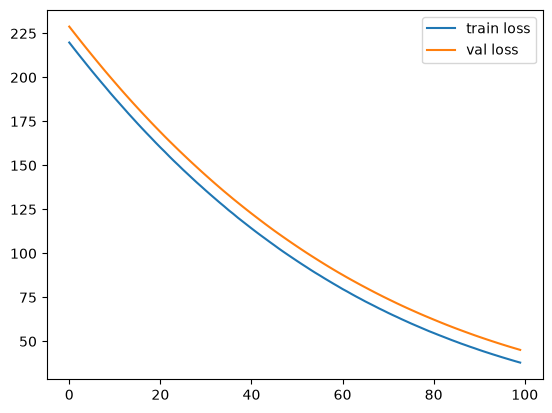

In [11]:
plt.plot(tr_loss_list, label='train loss')
plt.plot(val_loss_list, label='val loss') # CPU에서 처리가 된다 
plt.legend()
plt.show()